### Магистратура, 2 семестр
### Дисциплина: Высокопроизводительные вычисления
### Лабораторная работа №3 (Mass Search)
### Выполнил: 6133-010402D Журавлев Н.С.

### Проверка GPU и CUDA

In [52]:
!nvidia-smi
!nvcc --version

Tue Apr 14 18:55:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Установка расширения для запуска CUDA-кода в Google Colab

In [53]:
!pip -q install nvcc4jupyter
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


### CUDA-реализация массового поиска подстрок

In [54]:
%%writefile mass_search.cu

Overwriting mass_search.cu


In [55]:
%%cuda
#include <cuda_runtime.h>
#include <device_launch_parameters.h>

#include <algorithm>
#include <array>
#include <chrono>
#include <climits>
#include <cstdint>
#include <cstdlib>
#include <cstring>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <numeric>
#include <random>
#include <sstream>
#include <string>
#include <vector>

#define CHECK_CUDA(call)                                                        \
do {                                                                            \
    cudaError_t err__ = (call);                                                 \
    if (err__ != cudaSuccess) {                                                 \
        std::cerr << "CUDA error: " << cudaGetErrorString(err__)                \
                  << " at " << __FILE__ << ":" << __LINE__ << std::endl;        \
        std::exit(EXIT_FAILURE);                                                \
    }                                                                           \
} while (0)

constexpr int ALPHABET = 256;
__constant__ int c_occOffsets[ALPHABET + 1];

enum SearchMode {
    PRESENCE_ONLY = 0,
    ALL_POSITIONS = 1
};

struct Params {
    int h = 120000;               // длина буфера H
    int n = 256;                  // количество подстрок |N|
    int minLen = 4;               // минимальная длина подстроки
    int maxLen = 16;              // максимальная длина подстроки
    int mode = ALL_POSITIONS;     // 0 = только факт наличия, 1 = все позиции
    bool saveInput = true;        // сохранить входные данные в файлы
    int seed = 12345;             // seed для воспроизводимости
    int repeats = 3;              // число повторов для среднего времени
    bool injectMatches = true;    // гарантированно встроить часть шаблонов в H
    int maxPrintedPatterns = 25;  // сколько найденных шаблонов печатать
    int maxPrintedPositions = 20; // сколько позиций на шаблон печатать
};

struct Dataset {
    int h = 0;
    int n = 0;
    std::vector<unsigned char> text;
    std::vector<std::vector<unsigned char>> patterns;
    std::vector<int> lengths;

    // Для каждого байта c хранится диапазон [occOffsets[c], occOffsets[c+1))
    // в массивах occPatternIds / occPatternPos.
    std::vector<int> occOffsets;
    std::vector<int> occPatternIds;
    std::vector<int> occPatternPos;

    // Для контроля корректности: куда гарантированно встроили шаблон
    // (-1, если не встраивали).
    std::vector<int> injectedPos;

    size_t totalCells = 0; // |N| * |H|
};

struct SearchResults {
    std::vector<unsigned char> found;
    std::vector<std::vector<int>> positions;
    size_t totalMatches = 0;   // в режиме ALL_POSITIONS: число всех вхождений
                               // в режиме PRESENCE_ONLY: число найденных шаблонов
};

struct CpuRunResult {
    std::vector<int> R;
    double avgMs = 0.0;
};

struct GpuRunResult {
    std::vector<int> R;
    float setupMs = 0.0f;      // разовая подготовка GPU и H2D для статических структур
    float avgTotalMs = 0.0f;   // среднее время: инициализация R + kernel + D2H
    float avgKernelMs = 0.0f;  // среднее время только kernel
};

static std::string bytesToHex(const std::vector<unsigned char>& data) {
    std::ostringstream oss;
    oss << std::hex << std::setfill('0');
    for (size_t i = 0; i < data.size(); ++i) {
        oss << std::setw(2) << static_cast<int>(data[i]);
        if (i + 1 < data.size()) oss << ' ';
    }
    return oss.str();
}

static void printDeviceInfo() {
    int device = 0;
    cudaDeviceProp prop{};
    CHECK_CUDA(cudaGetDeviceProperties(&prop, device));

    std::cout << "===== GPU =====\n";
    std::cout << "Устройство: " << prop.name << "\n";
    std::cout << "Compute capability: " << prop.major << "." << prop.minor << "\n";
    std::cout << "Global memory: "
              << std::fixed << std::setprecision(2)
              << (static_cast<double>(prop.totalGlobalMem) / (1024.0 * 1024.0 * 1024.0))
              << " GiB\n\n";
}

static void preprocess(Dataset& d) {
    d.lengths.resize(d.n);
    std::array<std::vector<int>, ALPHABET> tempPatternIds;
    std::array<std::vector<int>, ALPHABET> tempPatternPos;

    for (int p = 0; p < d.n; ++p) {
        d.lengths[p] = static_cast<int>(d.patterns[p].size());
        for (int k = 0; k < d.lengths[p]; ++k) {
            unsigned char c = d.patterns[p][k];
            tempPatternIds[c].push_back(p);
            tempPatternPos[c].push_back(k);
        }
    }

    d.occOffsets.assign(ALPHABET + 1, 0);
    for (int c = 0; c < ALPHABET; ++c) {
        d.occOffsets[c + 1] = d.occOffsets[c] + static_cast<int>(tempPatternIds[c].size());
    }

    int totalOcc = d.occOffsets[ALPHABET];
    d.occPatternIds.resize(totalOcc);
    d.occPatternPos.resize(totalOcc);

    for (int c = 0; c < ALPHABET; ++c) {
        int base = d.occOffsets[c];
        for (size_t t = 0; t < tempPatternIds[c].size(); ++t) {
            d.occPatternIds[base + static_cast<int>(t)] = tempPatternIds[c][t];
            d.occPatternPos[base + static_cast<int>(t)] = tempPatternPos[c][t];
        }
    }

    d.totalCells = static_cast<size_t>(d.n) * static_cast<size_t>(d.h);
    if (d.totalCells > static_cast<size_t>(INT_MAX)) {
        std::cerr << "Слишком большая рабочая матрица: |N|*|H| > INT_MAX.\n";
        std::exit(EXIT_FAILURE);
    }
}

static Dataset generateDataset(const Params& params) {
    Dataset d;
    d.h = params.h;
    d.n = params.n;
    d.text.resize(d.h);
    d.patterns.resize(d.n);
    d.injectedPos.assign(d.n, -1);

    std::mt19937 rng(params.seed);
    std::uniform_int_distribution<int> byteDist(0, 255);
    std::uniform_int_distribution<int> lenDist(params.minLen, params.maxLen);

    for (int i = 0; i < d.h; ++i) {
        d.text[i] = static_cast<unsigned char>(byteDist(rng));
    }

    for (int p = 0; p < d.n; ++p) {
        int len = lenDist(rng);
        d.patterns[p].resize(len);
        for (int k = 0; k < len; ++k) {
            d.patterns[p][k] = static_cast<unsigned char>(byteDist(rng));
        }
    }

    // Гарантированно встроим часть шаблонов в текст, чтобы совпадения точно были.
    // Берем непересекающиеся регионы.
    if (params.injectMatches && d.h > params.maxLen) {
        int injectedCount = std::min(d.n, std::max(1, d.h / (params.maxLen + 2)));
        int regionSize = d.h / injectedCount;

        for (int p = 0; p < injectedCount; ++p) {
            int len = static_cast<int>(d.patterns[p].size());
            int left = p * regionSize;
            int right = std::min(d.h - len, left + regionSize - len);
            if (right < left) continue;

            std::uniform_int_distribution<int> posDist(left, right);
            int pos = posDist(rng);
            for (int k = 0; k < len; ++k) {
                d.text[pos + k] = d.patterns[p][k];
            }
            d.injectedPos[p] = pos;
        }
    }

    preprocess(d);
    return d;
}

static void saveInputFiles(const Dataset& d, const Params& params) {
    {
        std::ofstream fout("buffer.bin", std::ios::binary);
        fout.write(reinterpret_cast<const char*>(d.text.data()),
                   static_cast<std::streamsize>(d.text.size()));
    }

    {
        std::ofstream fout("patterns_hex.txt");
        for (int p = 0; p < d.n; ++p) {
            fout << "pattern_id=" << p
                 << " len=" << d.lengths[p]
                 << " injected_pos=" << d.injectedPos[p]
                 << "\n";
            fout << bytesToHex(d.patterns[p]) << "\n\n";
        }
    }

    {
        std::ofstream fout("input_meta.txt");
        fout << "h=" << params.h << "\n";
        fout << "n=" << params.n << "\n";
        fout << "minLen=" << params.minLen << "\n";
        fout << "maxLen=" << params.maxLen << "\n";
        fout << "mode=" << (params.mode == ALL_POSITIONS ? "ALL_POSITIONS" : "PRESENCE_ONLY") << "\n";
        fout << "seed=" << params.seed << "\n";
        fout << "repeats=" << params.repeats << "\n";
        fout << "injectMatches=" << (params.injectMatches ? 1 : 0) << "\n";
        fout << "matrix_cells=" << d.totalCells << "\n";
        fout << "occurrence_pairs=" << d.occPatternIds.size() << "\n";
    }
}

static CpuRunResult runCpu(const Dataset& d, int repeats) {
    CpuRunResult result;
    result.R.resize(d.totalCells);

    double totalMs = 0.0;

    for (int rep = 0; rep < repeats; ++rep) {
        auto t1 = std::chrono::high_resolution_clock::now();

        // Инициализация рабочей матрицы: каждая строка i заполняется длиной шаблона Ni
        for (int p = 0; p < d.n; ++p) {
            size_t rowBase = static_cast<size_t>(p) * static_cast<size_t>(d.h);
            std::fill(result.R.begin() + rowBase,
                      result.R.begin() + rowBase + d.h,
                      d.lengths[p]);
        }

        // Основная итерация
        for (int i = 0; i < d.h; ++i) {
            unsigned char c = d.text[i];
            int begin = d.occOffsets[c];
            int end = d.occOffsets[c + 1];

            for (int idx = begin; idx < end; ++idx) {
                int p = d.occPatternIds[idx];
                int k = d.occPatternPos[idx];
                int j = i - k;
                if (j >= 0) {
                    size_t cell = static_cast<size_t>(p) * static_cast<size_t>(d.h)
                                + static_cast<size_t>(j);
                    result.R[cell] -= 1;
                }
            }
        }

        auto t2 = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double, std::milli> ms = t2 - t1;
        totalMs += ms.count();
    }

    result.avgMs = totalMs / static_cast<double>(repeats);
    return result;
}

__global__ void searchKernel(const unsigned char* text,
                             int h,
                             const int* occPatternIds,
                             const int* occPatternPos,
                             int* R) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= h) return;

    unsigned char c = text[i];
    int begin = c_occOffsets[c];
    int end = c_occOffsets[c + 1];

    for (int idx = begin; idx < end; ++idx) {
        int p = occPatternIds[idx];
        int k = occPatternPos[idx];
        int j = i - k;
        if (j >= 0) {
            size_t cell = static_cast<size_t>(p) * static_cast<size_t>(h)
                        + static_cast<size_t>(j);
            atomicSub(&R[cell], 1);
        }
    }
}

static GpuRunResult runGpu(const Dataset& d, int repeats) {
    GpuRunResult result;
    result.R.resize(d.totalCells);

    std::vector<int> Rinit(d.totalCells);
    for (int p = 0; p < d.n; ++p) {
        size_t rowBase = static_cast<size_t>(p) * static_cast<size_t>(d.h);
        std::fill(Rinit.begin() + rowBase,
                  Rinit.begin() + rowBase + d.h,
                  d.lengths[p]);
    }

    unsigned char* d_text = nullptr;
    int* d_occPatternIds = nullptr;
    int* d_occPatternPos = nullptr;
    int* d_R = nullptr;

    const size_t textBytes = static_cast<size_t>(d.h) * sizeof(unsigned char);
    const size_t occBytes = static_cast<size_t>(d.occPatternIds.size()) * sizeof(int);
    const size_t Rbytes = d.totalCells * sizeof(int);

    CHECK_CUDA(cudaFree(0)); // warm-up CUDA runtime

    auto setupT1 = std::chrono::high_resolution_clock::now();

    CHECK_CUDA(cudaMalloc(&d_text, textBytes));
    CHECK_CUDA(cudaMalloc(&d_occPatternIds, occBytes));
    CHECK_CUDA(cudaMalloc(&d_occPatternPos, occBytes));
    CHECK_CUDA(cudaMalloc(&d_R, Rbytes));

    CHECK_CUDA(cudaMemcpy(d_text, d.text.data(), textBytes, cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpy(d_occPatternIds, d.occPatternIds.data(), occBytes, cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpy(d_occPatternPos, d.occPatternPos.data(), occBytes, cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpyToSymbol(c_occOffsets,
                                  d.occOffsets.data(),
                                  (ALPHABET + 1) * sizeof(int)));

    auto setupT2 = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> setupMs = setupT2 - setupT1;
    result.setupMs = static_cast<float>(setupMs.count());

    cudaEvent_t kStart, kStop;
    CHECK_CUDA(cudaEventCreate(&kStart));
    CHECK_CUDA(cudaEventCreate(&kStop));

    float totalMsSum = 0.0f;
    float kernelMsSum = 0.0f;

    const int blockSize = 256;
    const int gridSize = (d.h + blockSize - 1) / blockSize;

    for (int rep = 0; rep < repeats; ++rep) {
        auto totalT1 = std::chrono::high_resolution_clock::now();

        CHECK_CUDA(cudaMemcpy(d_R, Rinit.data(), Rbytes, cudaMemcpyHostToDevice));

        CHECK_CUDA(cudaEventRecord(kStart));
        searchKernel<<<gridSize, blockSize>>>(d_text, d.h, d_occPatternIds, d_occPatternPos, d_R);
        CHECK_CUDA(cudaEventRecord(kStop));

        CHECK_CUDA(cudaGetLastError());
        CHECK_CUDA(cudaEventSynchronize(kStop));

        float kernelMs = 0.0f;
        CHECK_CUDA(cudaEventElapsedTime(&kernelMs, kStart, kStop));
        kernelMsSum += kernelMs;

        CHECK_CUDA(cudaMemcpy(result.R.data(), d_R, Rbytes, cudaMemcpyDeviceToHost));

        auto totalT2 = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double, std::milli> totalMs = totalT2 - totalT1;
        totalMsSum += static_cast<float>(totalMs.count());
    }

    result.avgTotalMs = totalMsSum / static_cast<float>(repeats);
    result.avgKernelMs = kernelMsSum / static_cast<float>(repeats);

    CHECK_CUDA(cudaEventDestroy(kStart));
    CHECK_CUDA(cudaEventDestroy(kStop));
    CHECK_CUDA(cudaFree(d_text));
    CHECK_CUDA(cudaFree(d_occPatternIds));
    CHECK_CUDA(cudaFree(d_occPatternPos));
    CHECK_CUDA(cudaFree(d_R));

    return result;
}

static SearchResults extractResults(const Dataset& d,
                                    const std::vector<int>& R,
                                    int mode) {
    SearchResults out;
    out.found.assign(d.n, 0);
    if (mode == ALL_POSITIONS) {
        out.positions.resize(d.n);
    }

    for (int p = 0; p < d.n; ++p) {
        int len = d.lengths[p];
        int lastStart = d.h - len;
        bool any = false;

        if (lastStart >= 0) {
            size_t rowBase = static_cast<size_t>(p) * static_cast<size_t>(d.h);
            for (int j = 0; j <= lastStart; ++j) {
                if (R[rowBase + static_cast<size_t>(j)] == 0) {
                    any = true;
                    if (mode == ALL_POSITIONS) {
                        out.positions[p].push_back(j);
                        out.totalMatches += 1;
                    }
                }
            }
        }

        out.found[p] = any ? 1 : 0;
        if (mode == PRESENCE_ONLY && any) {
            out.totalMatches += 1;
        }
    }

    return out;
}

static std::string compareResults(const SearchResults& cpu,
                                  const SearchResults& gpu,
                                  int mode) {
    if (cpu.found.size() != gpu.found.size()) {
        return "Размеры результатов CPU и GPU различаются.";
    }

    for (size_t p = 0; p < cpu.found.size(); ++p) {
        if (cpu.found[p] != gpu.found[p]) {
            std::ostringstream oss;
            oss << "Несовпадение по шаблону " << p
                << ": CPU found=" << static_cast<int>(cpu.found[p])
                << ", GPU found=" << static_cast<int>(gpu.found[p]);
            return oss.str();
        }
    }

    if (mode == ALL_POSITIONS) {
        if (cpu.positions.size() != gpu.positions.size()) {
            return "Размеры списков позиций CPU и GPU различаются.";
        }

        for (size_t p = 0; p < cpu.positions.size(); ++p) {
            if (cpu.positions[p] != gpu.positions[p]) {
                std::ostringstream oss;
                oss << "Несовпадение позиций по шаблону " << p << ".";
                return oss.str();
            }
        }
    }

    return "Результаты CPU и GPU полностью совпадают.";
}

static void printResults(const Dataset& d,
                         const SearchResults& res,
                         const Params& params) {
    int foundPatterns = 0;
    for (unsigned char x : res.found) {
        foundPatterns += (x ? 1 : 0);
    }

    std::cout << "\n===== РЕЗУЛЬТАТЫ ПОИСКА =====\n";
    std::cout << "Найдено шаблонов: " << foundPatterns << " / " << d.n << "\n";
    if (params.mode == ALL_POSITIONS) {
        std::cout << "Всего найдено вхождений: " << res.totalMatches << "\n";
    } else {
        std::cout << "Число шаблонов, присутствующих в строке: " << res.totalMatches << "\n";
    }

    int printed = 0;
    for (int p = 0; p < d.n && printed < params.maxPrintedPatterns; ++p) {
        if (!res.found[p]) continue;

        std::cout << "Шаблон #" << p
                  << " (len=" << d.lengths[p] << ")";
        if (d.injectedPos[p] >= 0) {
            std::cout << ", гарантированно встроен в позицию " << d.injectedPos[p];
        }

        if (params.mode == ALL_POSITIONS) {
            std::cout << " -> позиции: ";
            const auto& pos = res.positions[p];
            int lim = std::min(static_cast<int>(pos.size()), params.maxPrintedPositions);
            for (int i = 0; i < lim; ++i) {
                std::cout << pos[i];
                if (i + 1 < lim) std::cout << ", ";
            }
            if (static_cast<int>(pos.size()) > params.maxPrintedPositions) {
                std::cout << ", ...";
            }
        } else {
            std::cout << " -> найден";
        }

        std::cout << "\n";
        printed++;
    }

    if (printed == 0) {
        std::cout << "Совпадений не найдено.\n";
    }
}

int main() {
    Params params;

    // ЗДЕСЬ МЕНЯТЬ ПАРАМЕТРЫ ДЛЯ ЭКСПЕРИМЕНТОВ
    params.h = 200000;
    params.n = 384;
    params.minLen = 4;
    params.maxLen = 16;
    params.mode = ALL_POSITIONS;   // PRESENCE_ONLY или ALL_POSITIONS
    params.saveInput = true;
    params.seed = 12345;
    params.repeats = 3;
    params.injectMatches = true;
    params.maxPrintedPatterns = 25;
    params.maxPrintedPositions = 20;

    if (params.minLen <= 0 || params.maxLen < params.minLen || params.maxLen >= params.h) {
        std::cerr << "Некорректные параметры: требуется 0 < minLen <= maxLen < h.\n";
        return 1;
    }

    printDeviceInfo();

    auto prepT1 = std::chrono::high_resolution_clock::now();
    Dataset data = generateDataset(params);
    auto prepT2 = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double, std::milli> prepMs = prepT2 - prepT1;

    if (params.saveInput) {
        saveInputFiles(data, params);
    }

    double matrixMiB = static_cast<double>(data.totalCells * sizeof(int)) / (1024.0 * 1024.0);

    std::cout << "===== ПАРАМЕТРЫ =====\n";
    std::cout << "h = " << params.h << "\n";
    std::cout << "|N| = " << params.n << "\n";
    std::cout << "minLen = " << params.minLen << "\n";
    std::cout << "maxLen = " << params.maxLen << "\n";
    std::cout << "mode = " << (params.mode == ALL_POSITIONS ? "ALL_POSITIONS" : "PRESENCE_ONLY") << "\n";
    std::cout << "repeats = " << params.repeats << "\n";
    std::cout << "seed = " << params.seed << "\n";
    std::cout << "Суммарное число пар (n, k): " << data.occPatternIds.size() << "\n";
    std::cout << "Размер рабочей матрицы R = |N| x |H| = "
              << params.n << " x " << params.h
              << " = " << data.totalCells << " элементов\n";
    std::cout << "Одна копия R занимает: "
              << std::fixed << std::setprecision(2) << matrixMiB << " MiB\n";
    std::cout << "Время генерации и preprocessing: "
              << std::fixed << std::setprecision(3) << prepMs.count() << " ms\n";
    if (params.saveInput) {
        std::cout << "Входные данные сохранены в файлы: buffer.bin, patterns_hex.txt, input_meta.txt\n";
    }

    CpuRunResult cpuRun = runCpu(data, params.repeats);
    SearchResults cpuResults = extractResults(data, cpuRun.R, params.mode);

    // Освободим память CPU-матрицы перед GPU, чтобы было комфортнее по RAM
    std::vector<int>().swap(cpuRun.R);

    GpuRunResult gpuRun = runGpu(data, params.repeats);
    SearchResults gpuResults = extractResults(data, gpuRun.R, params.mode);

    std::string cmp = compareResults(cpuResults, gpuResults, params.mode);

    std::cout << "\n===== ВРЕМЯ =====\n";
    std::cout << "CPU average time: " << std::fixed << std::setprecision(3)
              << cpuRun.avgMs << " ms\n";
    std::cout << "GPU setup time (разово): " << gpuRun.setupMs << " ms\n";
    std::cout << "GPU average total time: " << gpuRun.avgTotalMs << " ms\n";
    std::cout << "GPU average kernel time: " << gpuRun.avgKernelMs << " ms\n";

    if (gpuRun.avgTotalMs > 0.0f) {
        std::cout << "Speedup CPU / GPU total: "
                  << (cpuRun.avgMs / gpuRun.avgTotalMs) << "x\n";
    }
    if (gpuRun.avgKernelMs > 0.0f) {
        std::cout << "Speedup CPU / GPU kernel: "
                  << (cpuRun.avgMs / gpuRun.avgKernelMs) << "x\n";
    }

    std::cout << "\n===== СРАВНЕНИЕ CPU vs GPU =====\n";
    std::cout << cmp << "\n";

    printResults(data, gpuResults, params);

    {
        std::ofstream fout("metrics.csv");
        fout << "metric,value\n";
        fout << "cpu_avg_ms," << cpuRun.avgMs << "\n";
        fout << "gpu_setup_ms," << gpuRun.setupMs << "\n";
        fout << "gpu_avg_total_ms," << gpuRun.avgTotalMs << "\n";
        fout << "gpu_avg_kernel_ms," << gpuRun.avgKernelMs << "\n";
        fout << "speedup_total," << (gpuRun.avgTotalMs > 0.0f ? cpuRun.avgMs / gpuRun.avgTotalMs : 0.0) << "\n";
        fout << "speedup_kernel," << (gpuRun.avgKernelMs > 0.0f ? cpuRun.avgMs / gpuRun.avgKernelMs : 0.0) << "\n";
        fout << "found_patterns," << std::accumulate(gpuResults.found.begin(), gpuResults.found.end(), 0) << "\n";
        fout << "total_matches," << gpuResults.totalMatches << "\n";
    }

    {
        std::ofstream fout("found_patterns.csv");
        fout << "pattern_id,len,injected_pos,found,positions_count,first_pos\n";

        for (int p = 0; p < data.n; ++p) {
            int positionsCount = 0;
            int firstPos = -1;

            if (params.mode == ALL_POSITIONS) {
                positionsCount = static_cast<int>(gpuResults.positions[p].size());
                if (!gpuResults.positions[p].empty()) {
                    firstPos = gpuResults.positions[p][0];
                }
            } else {
                positionsCount = gpuResults.found[p] ? 1 : 0;
            }

            fout << p << ","
                 << data.lengths[p] << ","
                 << data.injectedPos[p] << ","
                 << static_cast<int>(gpuResults.found[p]) << ","
                 << positionsCount << ","
                 << firstPos << "\n";
        }
    }

    return 0;
}

===== GPU =====
Устройство: Tesla T4
Compute capability: 7.5
Global memory: 14.56 GiB

===== ПАРАМЕТРЫ =====
h = 200000
|N| = 384
minLen = 4
maxLen = 16
mode = ALL_POSITIONS
repeats = 3
seed = 12345
Суммарное число пар (n, k): 3846
Размер рабочей матрицы R = |N| x |H| = 384 x 200000 = 76800000 элементов
Одна копия R занимает: 292.97 MiB
Время генерации и preprocessing: 11.771 ms
Входные данные сохранены в файлы: buffer.bin, patterns_hex.txt, input_meta.txt

===== ВРЕМЯ =====
CPU average time: 449.609 ms
GPU setup time (разово): 0.576 ms
GPU average total time: 134.718 ms
GPU average kernel time: 3.898 ms
Speedup CPU / GPU total: 3.337x
Speedup CPU / GPU kernel: 115.331x

===== СРАВНЕНИЕ CPU vs GPU =====
Результаты CPU и GPU полностью совпадают.

===== РЕЗУЛЬТАТЫ ПОИСКА =====
Найдено шаблонов: 384 / 384
Всего найдено вхождений: 384
Шаблон #0 (len=10), гарантированно встроен в позицию 303 -> позиции: 303
Шаблон #1 (len=14), гарантированно встроен в позицию 645 -> позиции: 645
Шаблон #2 (

### Анализ результатов эксперимента

Таблица метрик:


,metric,value
0,cpu_avg_ms,449.609000
1,gpu_setup_ms,0.576456
2,gpu_avg_total_ms,134.718000
3,gpu_avg_kernel_ms,3.898410
4,speedup_total,3.337400
5,speedup_kernel,115.331000
6,found_patterns,384.000000
7,total_matches,384.000000


Первые строки по найденным шаблонам:


,pattern_id,len,injected_pos,found,positions_count,first_pos
0,0,10,303,1,1,303
1,1,14,645,1,1,645
2,2,10,1197,1,1,1197
3,3,7,1655,1,1,1655
4,4,12,2103,1,1,2103
5,5,8,2803,1,1,2803
6,6,15,3269,1,1,3269
7,7,10,4076,1,1,4076
8,8,11,4217,1,1,4217
9,9,8,5021,1,1,5021


Компактная таблица метрик:


metric,cpu_avg_ms,gpu_setup_ms,gpu_avg_total_ms,gpu_avg_kernel_ms,speedup_total,speedup_kernel,found_patterns,total_matches
value,449.609,0.576456,134.718,3.89841,3.3374,115.331,384.0,384.0


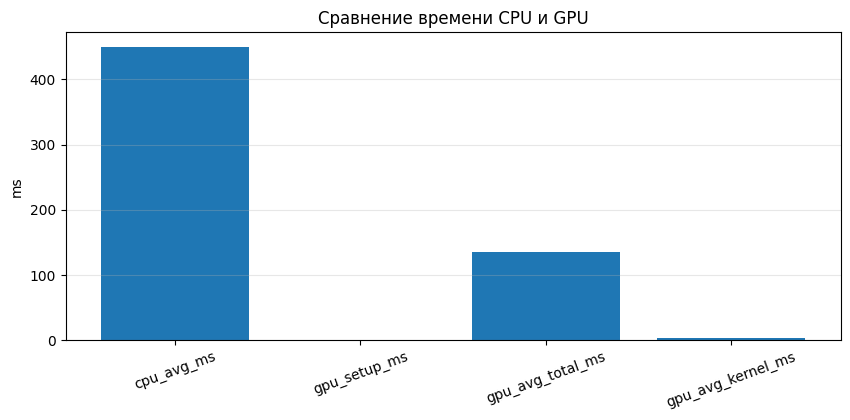

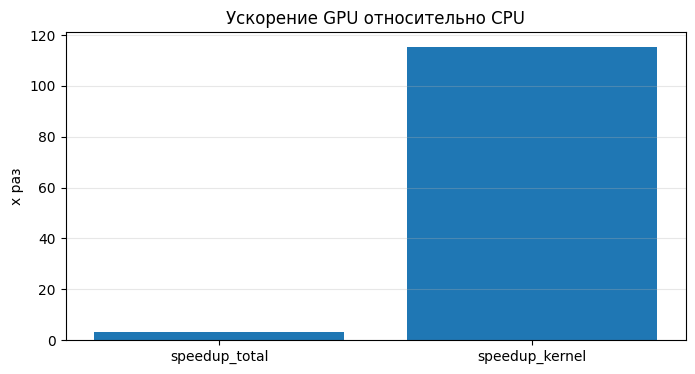

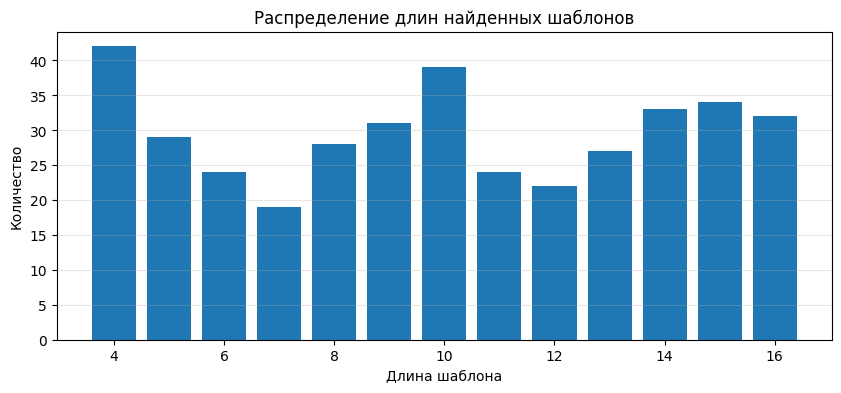

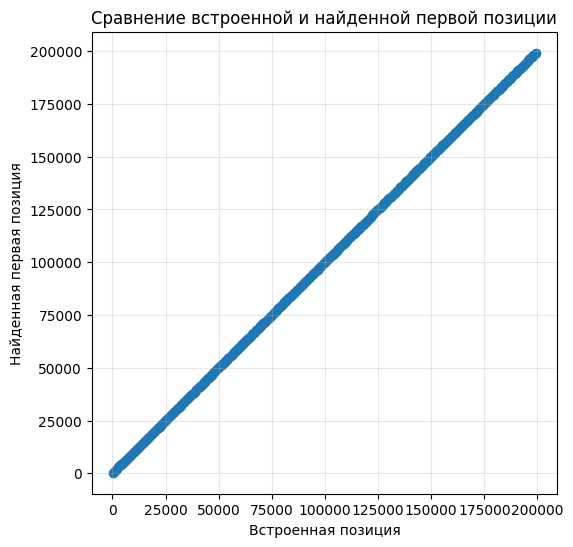

Таблица найденных шаблонов:


,pattern_id,len,injected_pos,positions_count,first_pos
0,0,10,303,1,303
1,1,14,645,1,645
2,2,10,1197,1,1197
3,3,7,1655,1,1655
4,4,12,2103,1,2103
...,...,...,...,...,...
379,379,6,197330,1,197330
380,380,9,197731,1,197731
381,381,14,198166,1,198166
382,382,16,198847,1,198847


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv("metrics.csv")
found = pd.read_csv("found_patterns.csv")

print("Таблица метрик:")
display(metrics)

print("Первые строки по найденным шаблонам:")
display(found.head(20))

metrics_wide = metrics.set_index("metric").T
print("Компактная таблица метрик:")
display(metrics_wide)

time_metrics = metrics[metrics["metric"].isin([
    "cpu_avg_ms", "gpu_setup_ms", "gpu_avg_total_ms", "gpu_avg_kernel_ms"
])]

plt.figure(figsize=(10, 4))
plt.bar(time_metrics["metric"], time_metrics["value"])
plt.title("Сравнение времени CPU и GPU")
plt.ylabel("ms")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

speed_metrics = metrics[metrics["metric"].isin(["speedup_total", "speedup_kernel"])]

plt.figure(figsize=(8, 4))
plt.bar(speed_metrics["metric"], speed_metrics["value"])
plt.title("Ускорение GPU относительно CPU")
plt.ylabel("x раз")
plt.grid(axis="y", alpha=0.3)
plt.show()

found_only = found[found["found"] == 1].copy()

if not found_only.empty:
    plt.figure(figsize=(10, 4))
    min_len = int(found_only["len"].min())
    max_len = int(found_only["len"].max())
    plt.hist(found_only["len"], bins=range(min_len, max_len + 2), align="left", rwidth=0.8)
    plt.title("Распределение длин найденных шаблонов")
    plt.xlabel("Длина шаблона")
    plt.ylabel("Количество")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("Гистограмма длин не строится: совпадений не найдено.")

matched_injected = found[(found["injected_pos"] >= 0) & (found["first_pos"] >= 0)].copy()

if not matched_injected.empty:
    plt.figure(figsize=(6, 6))
    plt.scatter(matched_injected["injected_pos"], matched_injected["first_pos"])
    plt.title("Сравнение встроенной и найденной первой позиции")
    plt.xlabel("Встроенная позиция")
    plt.ylabel("Найденная первая позиция")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("График встроенной/найденной позиции не строится: шаблоны не внедрялись или совпадения не найдены.")

summary = found_only[["pattern_id", "len", "injected_pos", "positions_count", "first_pos"]].copy()

print("Таблица найденных шаблонов:")
if not summary.empty:
    display(summary.sort_values(["pattern_id"]).reset_index(drop=True))
else:
    print("Совпадений нет, таблица найдённых шаблонов пуста.")